In [1]:
!pip install -q segmentation-models-pytorch timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

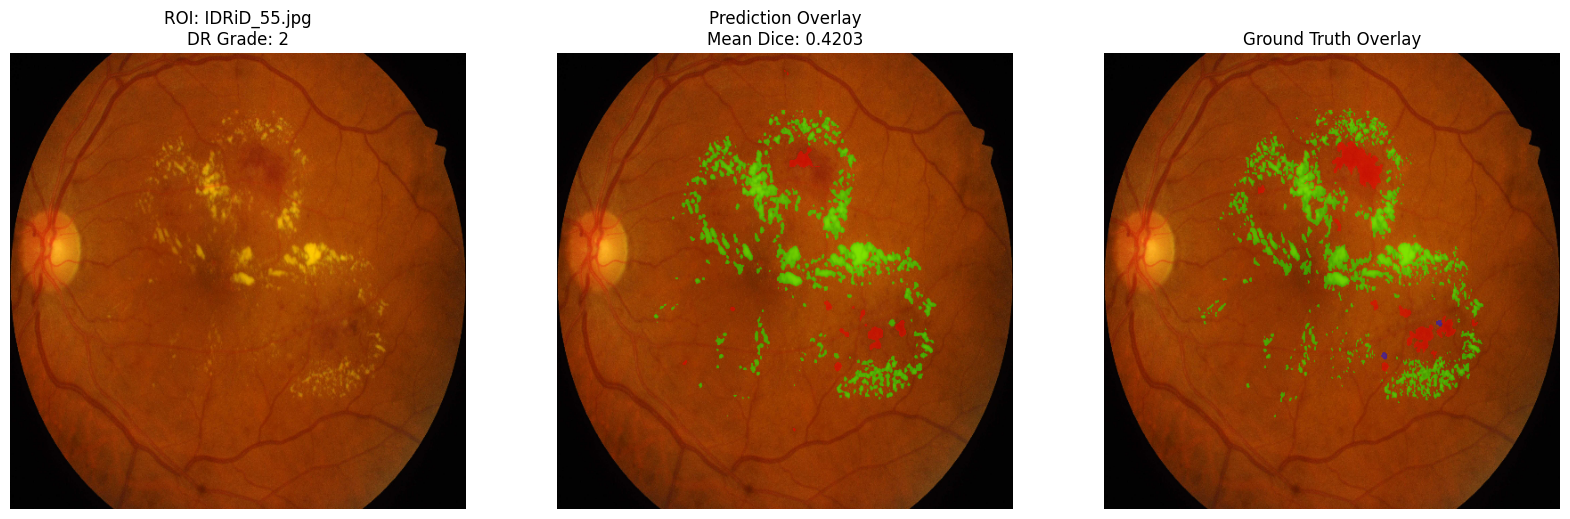

Metrics for IDRiD_55.jpg:
  HE         | Dice: 0.4759 | IoU: 0.3122
  EX         | Dice: 0.7849 | IoU: 0.6459
  SE         | Dice: 0.0000 | IoU: 0.0000


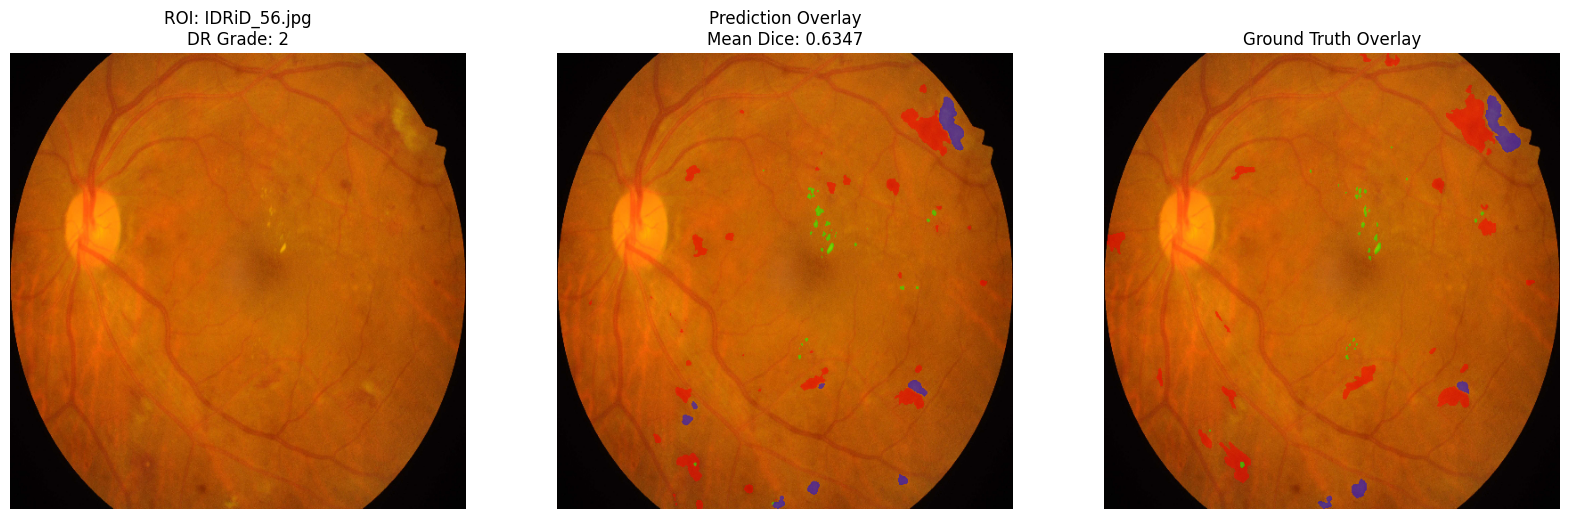

Metrics for IDRiD_56.jpg:
  HE         | Dice: 0.5980 | IoU: 0.4265
  EX         | Dice: 0.5896 | IoU: 0.4180
  SE         | Dice: 0.7165 | IoU: 0.5583


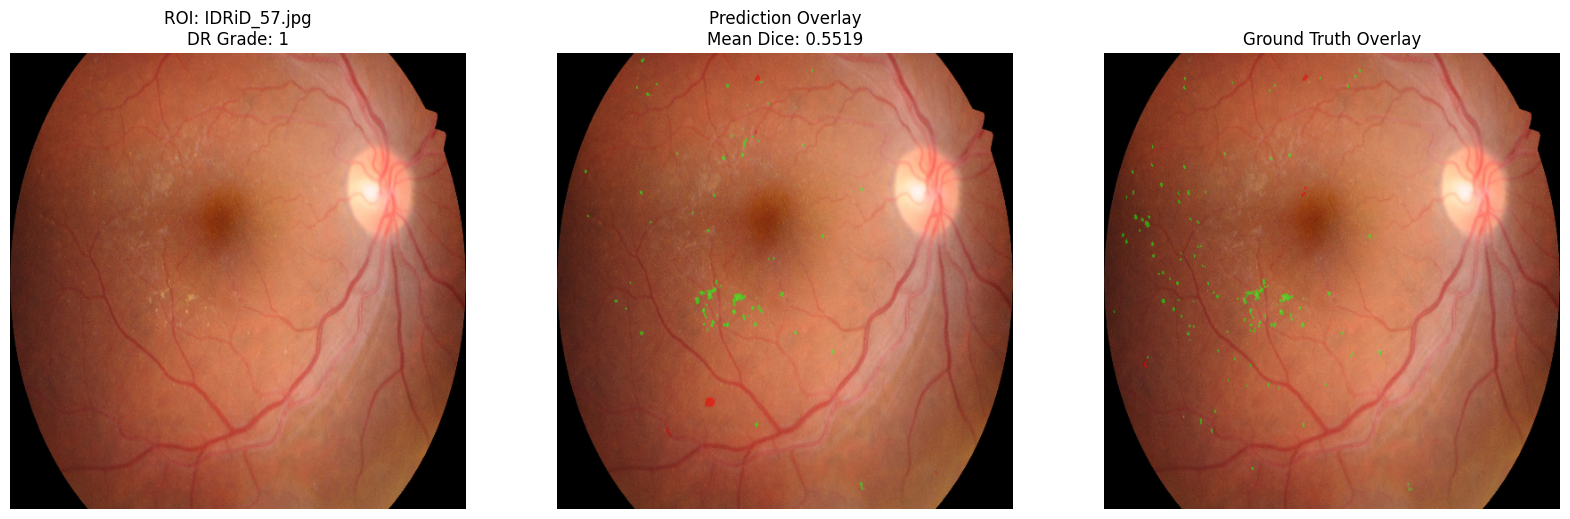

Metrics for IDRiD_57.jpg:
  HE         | Dice: 0.1835 | IoU: 0.1010
  EX         | Dice: 0.4721 | IoU: 0.3090
  SE         | Dice: 1.0000 | IoU: 1.0000


In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import transforms, models
import segmentation_models_pytorch as smp
from glob import glob
from PIL import Image
# --- 1. CONFIGURATION ---
class CFG:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    cl_img_size = 384
    seg_img_size = 512
    seg_classes = ["background", "HE", "EX", "SE"]
    
    # UPDATE PATHS
    cl_weights = "/kaggle/input/trained-models/aptos_2019 trained models/EfficientNetB4_model.pth"
    seg_weights = "/kaggle/input/effnet-unetv2/best_effnet_unet.pth"
    test_img_dir = "/kaggle/input/idrid-dataset/Segmentation/1. Original Images/b. Testing Set"
    gt_root = "/kaggle/input/idrid-dataset/Segmentation/2. All Segmentation Groundtruths/b. Testing Set"
# --- 2. METRICS CALCULATION ---
def calculate_metrics(pred, target, cls_idx, eps=1e-7):
    """Calculates Dice and IoU for a single class"""
    pred_c = (pred == cls_idx).astype(np.float32)
    target_c = (target == cls_idx).astype(np.float32)
    
    intersection = (pred_c * target_c).sum()
    union = pred_c.sum() + target_c.sum()
    
    dice = (2. * intersection + eps) / (union + eps)
    iou = (intersection + eps) / (union - intersection + eps)
    
    # If the class is absent in both, we consider it a perfect match (1.0)
    if union == 0:
        return 1.0, 1.0
    return dice, iou
# --- 3. MODEL DEFINITIONS ---
def get_classification_model(path, device):
    class APTOSModel(nn.Module):
        def __init__(self, num_classes=5):
            super().__init__()
            self.backbone = models.efficientnet_b4(weights=None)
            in_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Sequential(nn.Dropout(p=0.4), nn.Linear(in_features, num_classes))
        def forward(self, x): return self.backbone(x)
    model = APTOSModel()
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device).eval()
def get_segmentation_model(path, device):
    model = smp.Unet(encoder_name="efficientnet-b3", encoder_weights=None, in_channels=3, classes=4)
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device).eval()
# --- 4. PREPROCESSING & UTILS ---
def crop_fundus(image, threshold=10):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        return image[y:y+h, x:x+w], (x, y, w, h)
    return image, (0, 0, image.shape[1], image.shape[0])
def apply_clahe_green(image):
    green = image[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    g = clahe.apply(green)
    return np.stack([g, g, g], axis=-1)
def overlay_mask(image, mask, alpha=0.5):
    overlay = image.copy()
    colors = {1: [255, 0, 0], 2: [0, 255, 0], 3: [0, 0, 255]}
    for cls, color in colors.items():
        overlay[mask == cls] = (1 - alpha) * overlay[mask == cls] + alpha * np.array(color)
    return overlay.astype(np.uint8)
def load_gt_for_metrics(img_name, crop_coords):
    base_id = img_name.replace(".jpg", "")
    full_mask = np.zeros((CFG.seg_img_size, CFG.seg_img_size), dtype=np.uint8)
    mapping = {"HE": (1, "2. Haemorrhages"), "EX": (2, "3. Hard Exudates"), "SE": (3, "4. Soft Exudates")}
    x, y, w, h = crop_coords
    for lesion, (val, folder) in mapping.items():
        path = os.path.join(CFG.gt_root, folder, f"{base_id}_{lesion}.tif")
        if os.path.exists(path):
            m = cv2.imread(path, 0)[y:y+h, x:x+w]
            m = cv2.resize(m, (CFG.seg_img_size, CFG.seg_img_size), interpolation=cv2.INTER_NEAREST)
            full_mask[m > 0] = val
    return full_mask
# --- 5. PIPELINE EXECUTION ---
@torch.no_grad()
def run_pipeline(cl_model, seg_model, img_path):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # 1. Classification
    cl_trans = transforms.Compose([
        transforms.Resize((CFG.cl_img_size, CFG.cl_img_size)), transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    cl_inp = cl_trans(Image.fromarray(img_rgb)).unsqueeze(0).to(CFG.device)
    grade = torch.argmax(cl_model(cl_inp), dim=1).item()
    
    # 2. Segmentation
    cropped, coords = crop_fundus(img_rgb)
    roi = cv2.resize(cropped, (CFG.seg_img_size, CFG.seg_img_size))
    seg_inp = torch.tensor(np.transpose(apply_clahe_green(roi).astype(np.float32)/255.0, (2,0,1))).to(CFG.device)
    
    out_map = torch.zeros((4, 512, 512), device=CFG.device)
    cnt_map = torch.zeros((512, 512), device=CFG.device)
    for y in range(0, 512 - 256 + 1, 128):
        for x in range(0, 512 - 256 + 1, 128):
            patch = seg_inp[:, y:y+256, x:x+256].unsqueeze(0)
            out_map[:, y:y+256, x:x+256] += seg_model(patch)[0]
            cnt_map[y:y+256, x:x+256] += 1
            
    pred_mask = torch.argmax(out_map / cnt_map.unsqueeze(0), dim=0).cpu().numpy().astype(np.uint8)
    gt_mask = load_gt_for_metrics(os.path.basename(img_path), coords)
    
    # Calculate Metrics for HE (1), EX (2), SE (3)
    metrics = {}
    for i in range(1, 4):
        d, iou = calculate_metrics(pred_mask, gt_mask, i)
        metrics[CFG.seg_classes[i]] = {"Dice": d, "IoU": iou}
        
    return grade, roi, pred_mask, gt_mask, metrics
# --- 6. RUN AND PLOT ---
cl_m = get_classification_model(CFG.cl_weights, CFG.device)
seg_m = get_segmentation_model(CFG.seg_weights, CFG.device)
for path in sorted(glob(os.path.join(CFG.test_img_dir, "*.jpg")))[:3]:
    fname = os.path.basename(path)
    grade, roi, pred, gt, scores = run_pipeline(cl_m, seg_m, path)
    
    # Plotting
    avg_dice = np.mean([v['Dice'] for v in scores.values()])
    plt.figure(figsize=(20, 7))
    plt.subplot(1, 3, 1); plt.imshow(roi); plt.title(f"ROI: {fname}\nDR Grade: {grade}"); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(overlay_mask(roi, pred)); plt.title(f"Prediction Overlay\nMean Dice: {avg_dice:.4f}"); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(overlay_mask(roi, gt)); plt.title("Ground Truth Overlay"); plt.axis('off')
    plt.show()
    
    print(f"Metrics for {fname}:")
    for lesion, s in scores.items():
        print(f"  {lesion:10} | Dice: {s['Dice']:.4f} | IoU: {s['IoU']:.4f}")

In [3]:
import ipywidgets as widgets
from IPython.display import display, clear_output
# Configuration for both sets
DATASETS = {
    "Test Set": {
        "img_dir": "/kaggle/input/idrid-dataset/Segmentation/1. Original Images/b. Testing Set",
        "gt_dir": "/kaggle/input/idrid-dataset/Segmentation/2. All Segmentation Groundtruths/b. Testing Set"
    },
    "Train Set": {
        "img_dir": "/kaggle/input/idrid-dataset/Segmentation/1. Original Images/a. Training Set",
        "gt_dir": "/kaggle/input/idrid-dataset/Segmentation/2. All Segmentation Groundtruths/a. Training Set"
    }
}
# 1. Widgets Setup
dataset_toggle = widgets.Dropdown(
    options=["Test Set", "Train Set"],
    value="Test Set",
    description='Dataset:',
    style={'description_width': 'initial'}
)
image_dropdown = widgets.Dropdown(
    description='Image:',
    style={'description_width': 'initial'},
    layout={'width': 'max-content'}
)
analyze_button = widgets.Button(
    description='Analyze Image',
    button_style='success', 
    icon='play'
)
output_area = widgets.Output()
# 2. Logic to update image list based on dataset selection
def update_image_list(*args):
    selected_set = dataset_toggle.value
    img_dir = DATASETS[selected_set]["img_dir"]
    files = sorted([os.path.basename(p) for p in glob(os.path.join(img_dir, "*.jpg"))])
    image_dropdown.options = files
dataset_toggle.observe(update_image_list, 'value')
update_image_list() # Initial population
# 3. Analyze Function
def on_analyze_clicked(b):
    with output_area:
        clear_output()
        selected_set = dataset_toggle.value
        selected_file = image_dropdown.value
        
        img_path = os.path.join(DATASETS[selected_set]["img_dir"], selected_file)
        # Temporarily update CFG for the GT loader
        CFG.gt_root = DATASETS[selected_set]["gt_dir"]
        
        print(f"🔄 Processing  | {selected_file}...")
        
        try:
            grade, roi, pred, gt, scores = run_pipeline(cl_m, seg_m, img_path)
            
            # Visualization
            avg_dice = np.mean([v['Dice'] for v in scores.values()])
            plt.figure(figsize=(20, 7))
            
            plt.subplot(1, 3, 1)
            plt.imshow(roi)
            plt.title(f"ROI: {selected_file}\nPred DR Grade: {grade}")
            plt.axis('off')
            
            plt.subplot(1, 3, 2)
            plt.imshow(overlay_mask(roi, pred))
            plt.title(f"Prediction Overlay\nMean Dice: {avg_dice:.4f}")
            plt.axis('off')
            
            plt.subplot(1, 3, 3)
            plt.imshow(overlay_mask(roi, gt))
            plt.title("Ground Truth Overlay")
            plt.axis('off')
            
            plt.show()
            
            # Metrics
            print(f"\n📊 Metrics for {selected_file}:")
            print(f"{'Lesion':<12} | {'Dice':<10} | {'IoU':<10}")
            print("-" * 35)
            for lesion, s in scores.items():
                print(f"{lesion:<12} | {s['Dice']:.4f}     | {s['IoU']:.4f}")
                
        except Exception as e:
            print(f"❌ Error: {e}")
analyze_button.on_click(on_analyze_clicked)
# 4. Display UI
print("⚙️ Interactive Full Pipeline Dashboard")
ui = widgets.VBox([
    widgets.HBox([dataset_toggle, image_dropdown, analyze_button]),
    output_area
])
display(ui)

⚙️ Interactive Full Pipeline Dashboard


In [4]:
import ipywidgets as widgets
from IPython.display import display, clear_output
# Configuration for both sets
DATASETS = {
    "Test Set": {
        "img_dir": "/kaggle/input/idrid-dataset/Segmentation/1. Original Images/b. Testing Set",
        "gt_dir": "/kaggle/input/idrid-dataset/Segmentation/2. All Segmentation Groundtruths/b. Testing Set"
    },
    "Train Set": {
        "img_dir": "/kaggle/input/idrid-dataset/Segmentation/1. Original Images/a. Training Set",
        "gt_dir": "/kaggle/input/idrid-dataset/Segmentation/2. All Segmentation Groundtruths/a. Training Set"
    }
}
# 1. Widgets Setup
dataset_toggle = widgets.Dropdown(
    options=["Test Set", "Train Set"],
    value="Test Set",
    description='Dataset:',
    style={'description_width': 'initial'}
)
image_dropdown = widgets.Dropdown(
    description='Image:',
    style={'description_width': 'initial'},
    layout={'width': 'max-content'}
)
analyze_button = widgets.Button(
    description='Analyze Image',
    button_style='success', 
    icon='play'
)
output_area = widgets.Output()
# 2. Logic to update image list based on dataset selection
def update_image_list(*args):
    selected_set = dataset_toggle.value
    img_dir = DATASETS[selected_set]["img_dir"]
    files = sorted([os.path.basename(p) for p in glob(os.path.join(img_dir, "*.jpg"))])
    image_dropdown.options = files
dataset_toggle.observe(update_image_list, 'value')
update_image_list() # Initial population
# 3. Analyze Function
def on_analyze_clicked(b):
    with output_area:
        clear_output()
        selected_set = dataset_toggle.value
        selected_file = image_dropdown.value
        
        img_path = os.path.join(DATASETS[selected_set]["img_dir"], selected_file)
        # Temporarily update CFG for the GT loader
        CFG.gt_root = DATASETS[selected_set]["gt_dir"]
        
        print(f"🔄 Processing  | {selected_file}...")
        
        try:
            grade, roi, pred, gt, scores = run_pipeline(cl_m, seg_m, img_path)
            
            # Visualization
            avg_dice = np.mean([v['Dice'] for v in scores.values()])
            plt.figure(figsize=(20, 7))
            
            plt.subplot(1, 3, 1)
            plt.imshow(roi)
            plt.title(f"ROI: {selected_file}\nPred DR Grade: {grade}")
            plt.axis('off')
            
            plt.subplot(1, 3, 2)
            plt.imshow(overlay_mask(roi, pred))
            plt.title(f"Prediction Overlay\nMean Dice: {avg_dice:.4f}")
            plt.axis('off')
            
            plt.subplot(1, 3, 3)
            plt.imshow(overlay_mask(roi, gt))
            plt.title("Ground Truth Overlay")
            plt.axis('off')
            
            plt.show()
            
            # Metrics
            print(f"\n📊 Metrics for {selected_file}:")
            print(f"{'Lesion':<12} | {'Dice':<10} | {'IoU':<10}")
            print("-" * 35)
            for lesion, s in scores.items():
                print(f"{lesion:<12} | {s['Dice']:.4f}     | {s['IoU']:.4f}")
                
        except Exception as e:
            print(f"❌ Error: {e}")
analyze_button.on_click(on_analyze_clicked)
# 4. Display UI
print("⚙️ Interactive Full Pipeline Dashboard")
ui = widgets.VBox([
    widgets.HBox([dataset_toggle, image_dropdown, analyze_button]),
    output_area
])
display(ui)

⚙️ Interactive Full Pipeline Dashboard


In [5]:
import ipywidgets as widgets
from IPython.display import display, clear_output
# Configuration for both sets
DATASETS = {
    "Test Set": {
        "img_dir": "/kaggle/input/idrid-dataset/Segmentation/1. Original Images/b. Testing Set",
        "gt_dir": "/kaggle/input/idrid-dataset/Segmentation/2. All Segmentation Groundtruths/b. Testing Set"
    },
    "Train Set": {
        "img_dir": "/kaggle/input/idrid-dataset/Segmentation/1. Original Images/a. Training Set",
        "gt_dir": "/kaggle/input/idrid-dataset/Segmentation/2. All Segmentation Groundtruths/a. Training Set"
    }
}
# 1. Widgets Setup
dataset_toggle = widgets.Dropdown(
    options=["Test Set", "Train Set"],
    value="Test Set",
    description='Dataset:',
    style={'description_width': 'initial'}
)
image_dropdown = widgets.Dropdown(
    description='Image:',
    style={'description_width': 'initial'},
    layout={'width': 'max-content'}
)
analyze_button = widgets.Button(
    description='Analyze Image',
    button_style='success', 
    icon='play'
)
output_area = widgets.Output()
# 2. Logic to update image list based on dataset selection
def update_image_list(*args):
    selected_set = dataset_toggle.value
    img_dir = DATASETS[selected_set]["img_dir"]
    files = sorted([os.path.basename(p) for p in glob(os.path.join(img_dir, "*.jpg"))])
    image_dropdown.options = files
dataset_toggle.observe(update_image_list, 'value')
update_image_list() # Initial population
# 3. Analyze Function
def on_analyze_clicked(b):
    with output_area:
        clear_output()
        selected_set = dataset_toggle.value
        selected_file = image_dropdown.value
        
        img_path = os.path.join(DATASETS[selected_set]["img_dir"], selected_file)
        # Temporarily update CFG for the GT loader
        CFG.gt_root = DATASETS[selected_set]["gt_dir"]
        
        print(f"🔄 Processing  | {selected_file}...")
        
        try:
            grade, roi, pred, gt, scores = run_pipeline(cl_m, seg_m, img_path)
            
            # Visualization
            avg_dice = np.mean([v['Dice'] for v in scores.values()])
            plt.figure(figsize=(20, 7))
            
            plt.subplot(1, 3, 1)
            plt.imshow(roi)
            plt.title(f"ROI: {selected_file}\nPred DR Grade: {grade}")
            plt.axis('off')
            
            plt.subplot(1, 3, 2)
            plt.imshow(overlay_mask(roi, pred))
            plt.title(f"Prediction Overlay\nMean Dice: {avg_dice:.4f}")
            plt.axis('off')
            
            plt.subplot(1, 3, 3)
            plt.imshow(overlay_mask(roi, gt))
            plt.title("Ground Truth Overlay")
            plt.axis('off')
            
            plt.show()
            
            # Metrics
            print(f"\n📊 Metrics for {selected_file}:")
            print(f"{'Lesion':<12} | {'Dice':<10} | {'IoU':<10}")
            print("-" * 35)
            for lesion, s in scores.items():
                print(f"{lesion:<12} | {s['Dice']:.4f}     | {s['IoU']:.4f}")
                
        except Exception as e:
            print(f"❌ Error: {e}")
analyze_button.on_click(on_analyze_clicked)
# 4. Display UI
print("⚙️ Interactive Full Pipeline Dashboard")
ui = widgets.VBox([
    widgets.HBox([dataset_toggle, image_dropdown, analyze_button]),
    output_area
])
display(ui)

⚙️ Interactive Full Pipeline Dashboard


In [6]:
import ipywidgets as widgets
from IPython.display import display, clear_output
# Configuration for both sets
DATASETS = {
    "Test Set": {
        "img_dir": "/kaggle/input/idrid-dataset/Segmentation/1. Original Images/b. Testing Set",
        "gt_dir": "/kaggle/input/idrid-dataset/Segmentation/2. All Segmentation Groundtruths/b. Testing Set"
    },
    "Train Set": {
        "img_dir": "/kaggle/input/idrid-dataset/Segmentation/1. Original Images/a. Training Set",
        "gt_dir": "/kaggle/input/idrid-dataset/Segmentation/2. All Segmentation Groundtruths/a. Training Set"
    }
}
# 1. Widgets Setup
dataset_toggle = widgets.Dropdown(
    options=["Test Set", "Train Set"],
    value="Test Set",
    description='Dataset:',
    style={'description_width': 'initial'}
)
image_dropdown = widgets.Dropdown(
    description='Image:',
    style={'description_width': 'initial'},
    layout={'width': 'max-content'}
)
analyze_button = widgets.Button(
    description='Analyze Image',
    button_style='success', 
    icon='play'
)
output_area = widgets.Output()
# 2. Logic to update image list based on dataset selection
def update_image_list(*args):
    selected_set = dataset_toggle.value
    img_dir = DATASETS[selected_set]["img_dir"]
    files = sorted([os.path.basename(p) for p in glob(os.path.join(img_dir, "*.jpg"))])
    image_dropdown.options = files
dataset_toggle.observe(update_image_list, 'value')
update_image_list() # Initial population
# 3. Analyze Function
def on_analyze_clicked(b):
    with output_area:
        clear_output()
        selected_set = dataset_toggle.value
        selected_file = image_dropdown.value
        
        img_path = os.path.join(DATASETS[selected_set]["img_dir"], selected_file)
        # Temporarily update CFG for the GT loader
        CFG.gt_root = DATASETS[selected_set]["gt_dir"]
        
        print(f"🔄 Processing  | {selected_file}...")
        
        try:
            grade, roi, pred, gt, scores = run_pipeline(cl_m, seg_m, img_path)
            
            # Visualization
            avg_dice = np.mean([v['Dice'] for v in scores.values()])
            plt.figure(figsize=(20, 7))
            
            plt.subplot(1, 3, 1)
            plt.imshow(roi)
            plt.title(f"ROI: {selected_file}\nPred DR Grade: {grade}")
            plt.axis('off')
            
            plt.subplot(1, 3, 2)
            plt.imshow(overlay_mask(roi, pred))
            plt.title(f"Prediction Overlay\nMean Dice: {avg_dice:.4f}")
            plt.axis('off')
            
            plt.subplot(1, 3, 3)
            plt.imshow(overlay_mask(roi, gt))
            plt.title("Ground Truth Overlay")
            plt.axis('off')
            
            plt.show()
            
            # Metrics
            print(f"\n📊 Metrics for {selected_file}:")
            print(f"{'Lesion':<12} | {'Dice':<10} | {'IoU':<10}")
            print("-" * 35)
            for lesion, s in scores.items():
                print(f"{lesion:<12} | {s['Dice']:.4f}     | {s['IoU']:.4f}")
                
        except Exception as e:
            print(f"❌ Error: {e}")
analyze_button.on_click(on_analyze_clicked)
# 4. Display UI
print("⚙️ Interactive Full Pipeline Dashboard")
ui = widgets.VBox([
    widgets.HBox([dataset_toggle, image_dropdown, analyze_button]),
    output_area
])
display(ui)

⚙️ Interactive Full Pipeline Dashboard


In [7]:
import ipywidgets as widgets
from IPython.display import display, clear_output
# Configuration for both sets
DATASETS = {
    "Test Set": {
        "img_dir": "/kaggle/input/idrid-dataset/Segmentation/1. Original Images/b. Testing Set",
        "gt_dir": "/kaggle/input/idrid-dataset/Segmentation/2. All Segmentation Groundtruths/b. Testing Set"
    },
    "Train Set": {
        "img_dir": "/kaggle/input/idrid-dataset/Segmentation/1. Original Images/a. Training Set",
        "gt_dir": "/kaggle/input/idrid-dataset/Segmentation/2. All Segmentation Groundtruths/a. Training Set"
    }
}
# 1. Widgets Setup
dataset_toggle = widgets.Dropdown(
    options=["Test Set", "Train Set"],
    value="Test Set",
    description='Dataset:',
    style={'description_width': 'initial'}
)
image_dropdown = widgets.Dropdown(
    description='Image:',
    style={'description_width': 'initial'},
    layout={'width': 'max-content'}
)
analyze_button = widgets.Button(
    description='Analyze Image',
    button_style='success', 
    icon='play'
)
output_area = widgets.Output()
# 2. Logic to update image list based on dataset selection
def update_image_list(*args):
    selected_set = dataset_toggle.value
    img_dir = DATASETS[selected_set]["img_dir"]
    files = sorted([os.path.basename(p) for p in glob(os.path.join(img_dir, "*.jpg"))])
    image_dropdown.options = files
dataset_toggle.observe(update_image_list, 'value')
update_image_list() # Initial population
# 3. Analyze Function
def on_analyze_clicked(b):
    with output_area:
        clear_output()
        selected_set = dataset_toggle.value
        selected_file = image_dropdown.value
        
        img_path = os.path.join(DATASETS[selected_set]["img_dir"], selected_file)
        # Temporarily update CFG for the GT loader
        CFG.gt_root = DATASETS[selected_set]["gt_dir"]
        
        print(f"🔄 Processing  | {selected_file}...")
        
        try:
            grade, roi, pred, gt, scores = run_pipeline(cl_m, seg_m, img_path)
            
            # Visualization
            avg_dice = np.mean([v['Dice'] for v in scores.values()])
            plt.figure(figsize=(20, 7))
            
            plt.subplot(1, 3, 1)
            plt.imshow(roi)
            plt.title(f"ROI: {selected_file}\nPred DR Grade: {grade}")
            plt.axis('off')
            
            plt.subplot(1, 3, 2)
            plt.imshow(overlay_mask(roi, pred))
            plt.title(f"Prediction Overlay\nMean Dice: {avg_dice:.4f}")
            plt.axis('off')
            
            plt.subplot(1, 3, 3)
            plt.imshow(overlay_mask(roi, gt))
            plt.title("Ground Truth Overlay")
            plt.axis('off')
            
            plt.show()
            
            # Metrics
            print(f"\n📊 Metrics for {selected_file}:")
            print(f"{'Lesion':<12} | {'Dice':<10} | {'IoU':<10}")
            print("-" * 35)
            for lesion, s in scores.items():
                print(f"{lesion:<12} | {s['Dice']:.4f}     | {s['IoU']:.4f}")
                
        except Exception as e:
            print(f"❌ Error: {e}")
analyze_button.on_click(on_analyze_clicked)
# 4. Display UI
print("⚙️ Interactive Full Pipeline Dashboard")
ui = widgets.VBox([
    widgets.HBox([dataset_toggle, image_dropdown, analyze_button]),
    output_area
])
display(ui)

⚙️ Interactive Full Pipeline Dashboard
